In [1]:
#---------------Essential libraries------------------ 
import pandas as pd  
import numpy as np
#--------------visulation libraries----------------
import matplotlib.pyplot as plt 
%matplotlib inline 
import seaborn as sns
#-------------sklean essentials-----------
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

## **step 1. load dataset**
---
Goal : Predict California house prices using housing features such as income, average rooms, population, and location. 


In [2]:
housing= fetch_california_housing(as_frame=True)

df=pd.DataFrame(data=housing.data,columns=housing.feature_names)
print(f'dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df['Price']=housing.target # adding target variable to df 
df.head()

dataset shape: 20640 rows x 8 columns


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## **step 2. Explore and understand the dataset** 
**we inspect:**
 -Data types 
 -Missing values 
 -Statistical summery 
 -Duplicate record

In [3]:
print("==Data types & non-null counts===")
df.info()

==Data types & non-null counts===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
print(df.isnull().sum())
print('=='*30)
print(f"total number of missing values: {df.isnull().sum().sum()}")
print('--'*30)

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64
total number of missing values: 0
------------------------------------------------------------


In [5]:
print('-'*30)
print("== Statistical report==")
print('-'*30)
df.describe()


------------------------------
== Statistical report==
------------------------------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
print(df.duplicated().sum() )#missing duplicate check

0


## **step 3. Feature engineering :**

In [7]:
#can i calculate cost of one room ? no because of dataleakage (as price is target variable)
# we don't know the price before the model predicts 
df["Rooms_Per_Household"]=df['AveRooms']/df['AveOccup']
df['BedRooms_Per_Rooms']=df['AveBedrms']/df['AveRooms']
df["population_per_household"]=df["Population"]/df["AveOccup"]
print(' new feature created :      |')
print("--"*20)
print(' 1.-> Rooms per household : |')
print(' 2.-> Bed Rooms per Room  : |')
print(' 3.-> poputaion per house : |')

 new feature created :      |
----------------------------------------
 1.-> Rooms per household : |
 2.-> Bed Rooms per Room  : |
 3.-> poputaion per house : |


## **step 4. visulise the dataset**

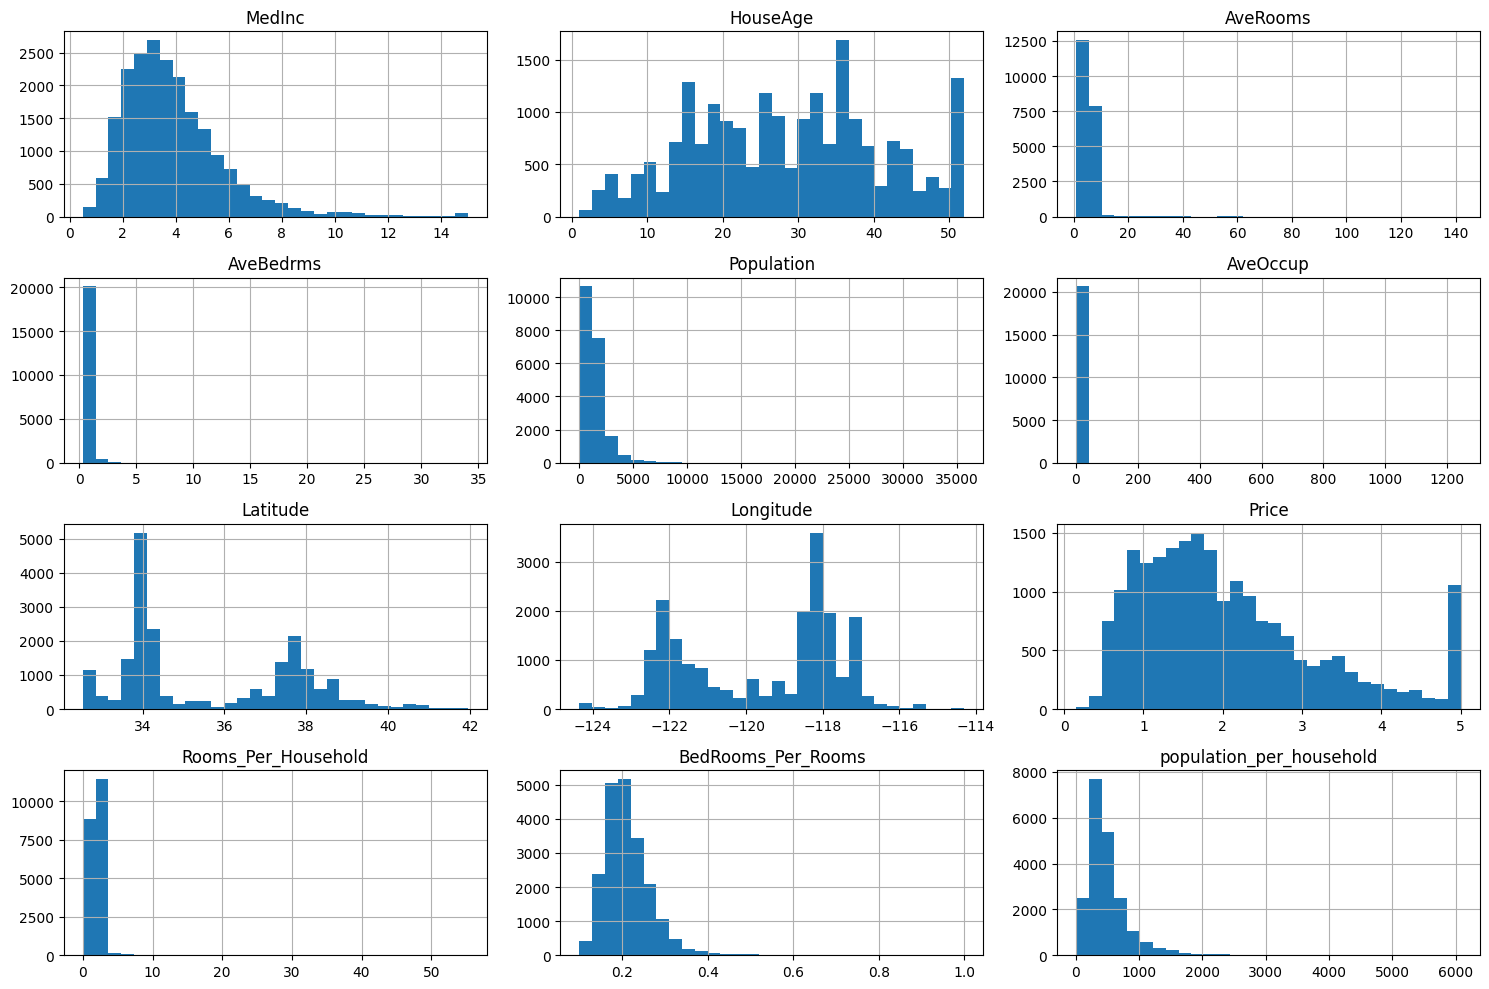

In [8]:
df.hist(figsize=(15,10),bins=30)
plt.tight_layout()
plt.show()



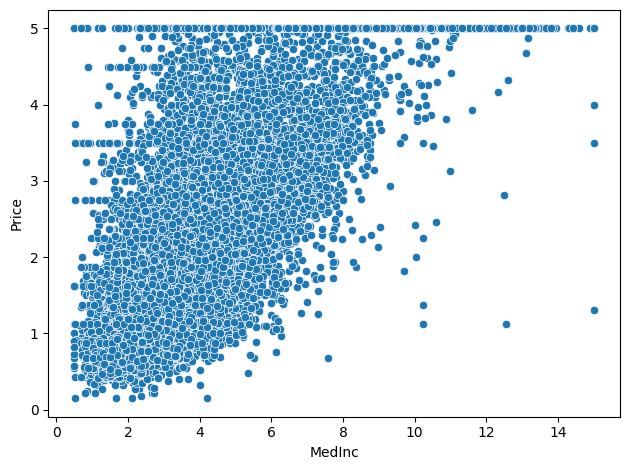

In [9]:
sns.scatterplot(
    x='MedInc',
    y='Price',
    data=df,
    )
plt.tight_layout()
plt.show()


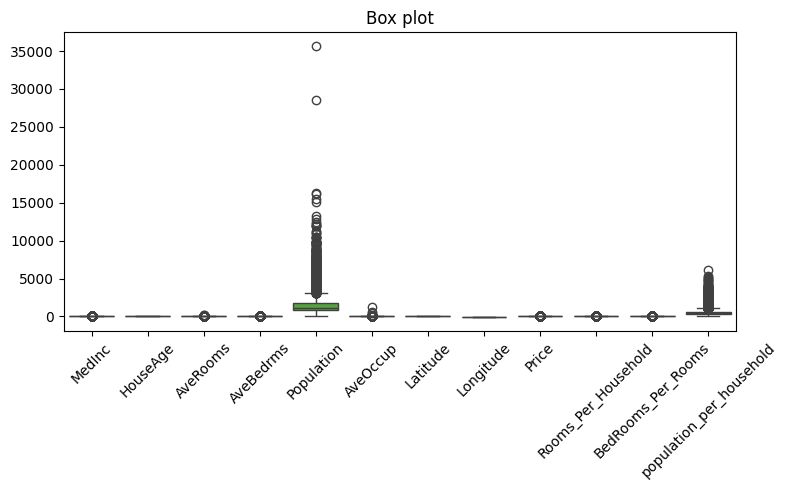

In [10]:
#box plot show outliers :
plt.figure(figsize=(8,5))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title('Box plot')
plt.tight_layout()
plt.show()


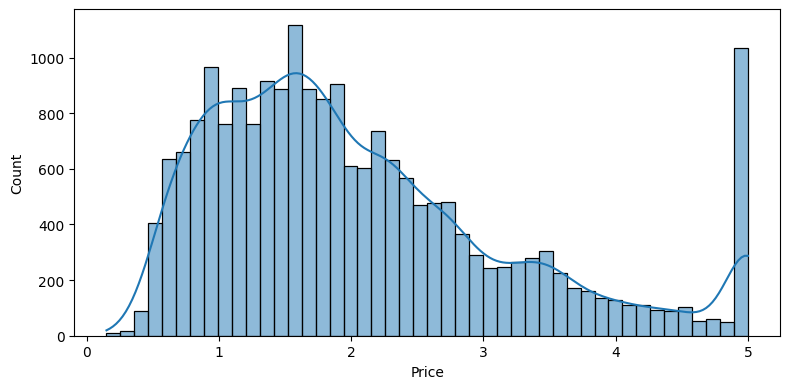

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(df['Price'], kde=True)
plt.tight_layout()
plt.show()

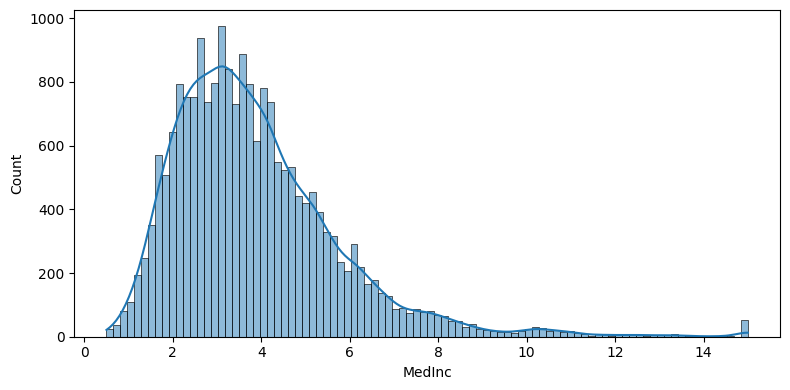

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df['MedInc'], kde=True)
plt.tight_layout()
plt.show()

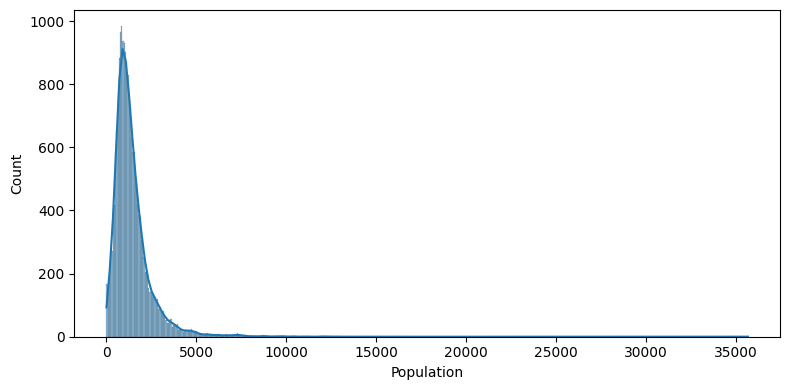

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(df['Population'], kde=True)

plt.tight_layout()
plt.show()

*Here, we can clearly see population has do many outliers*

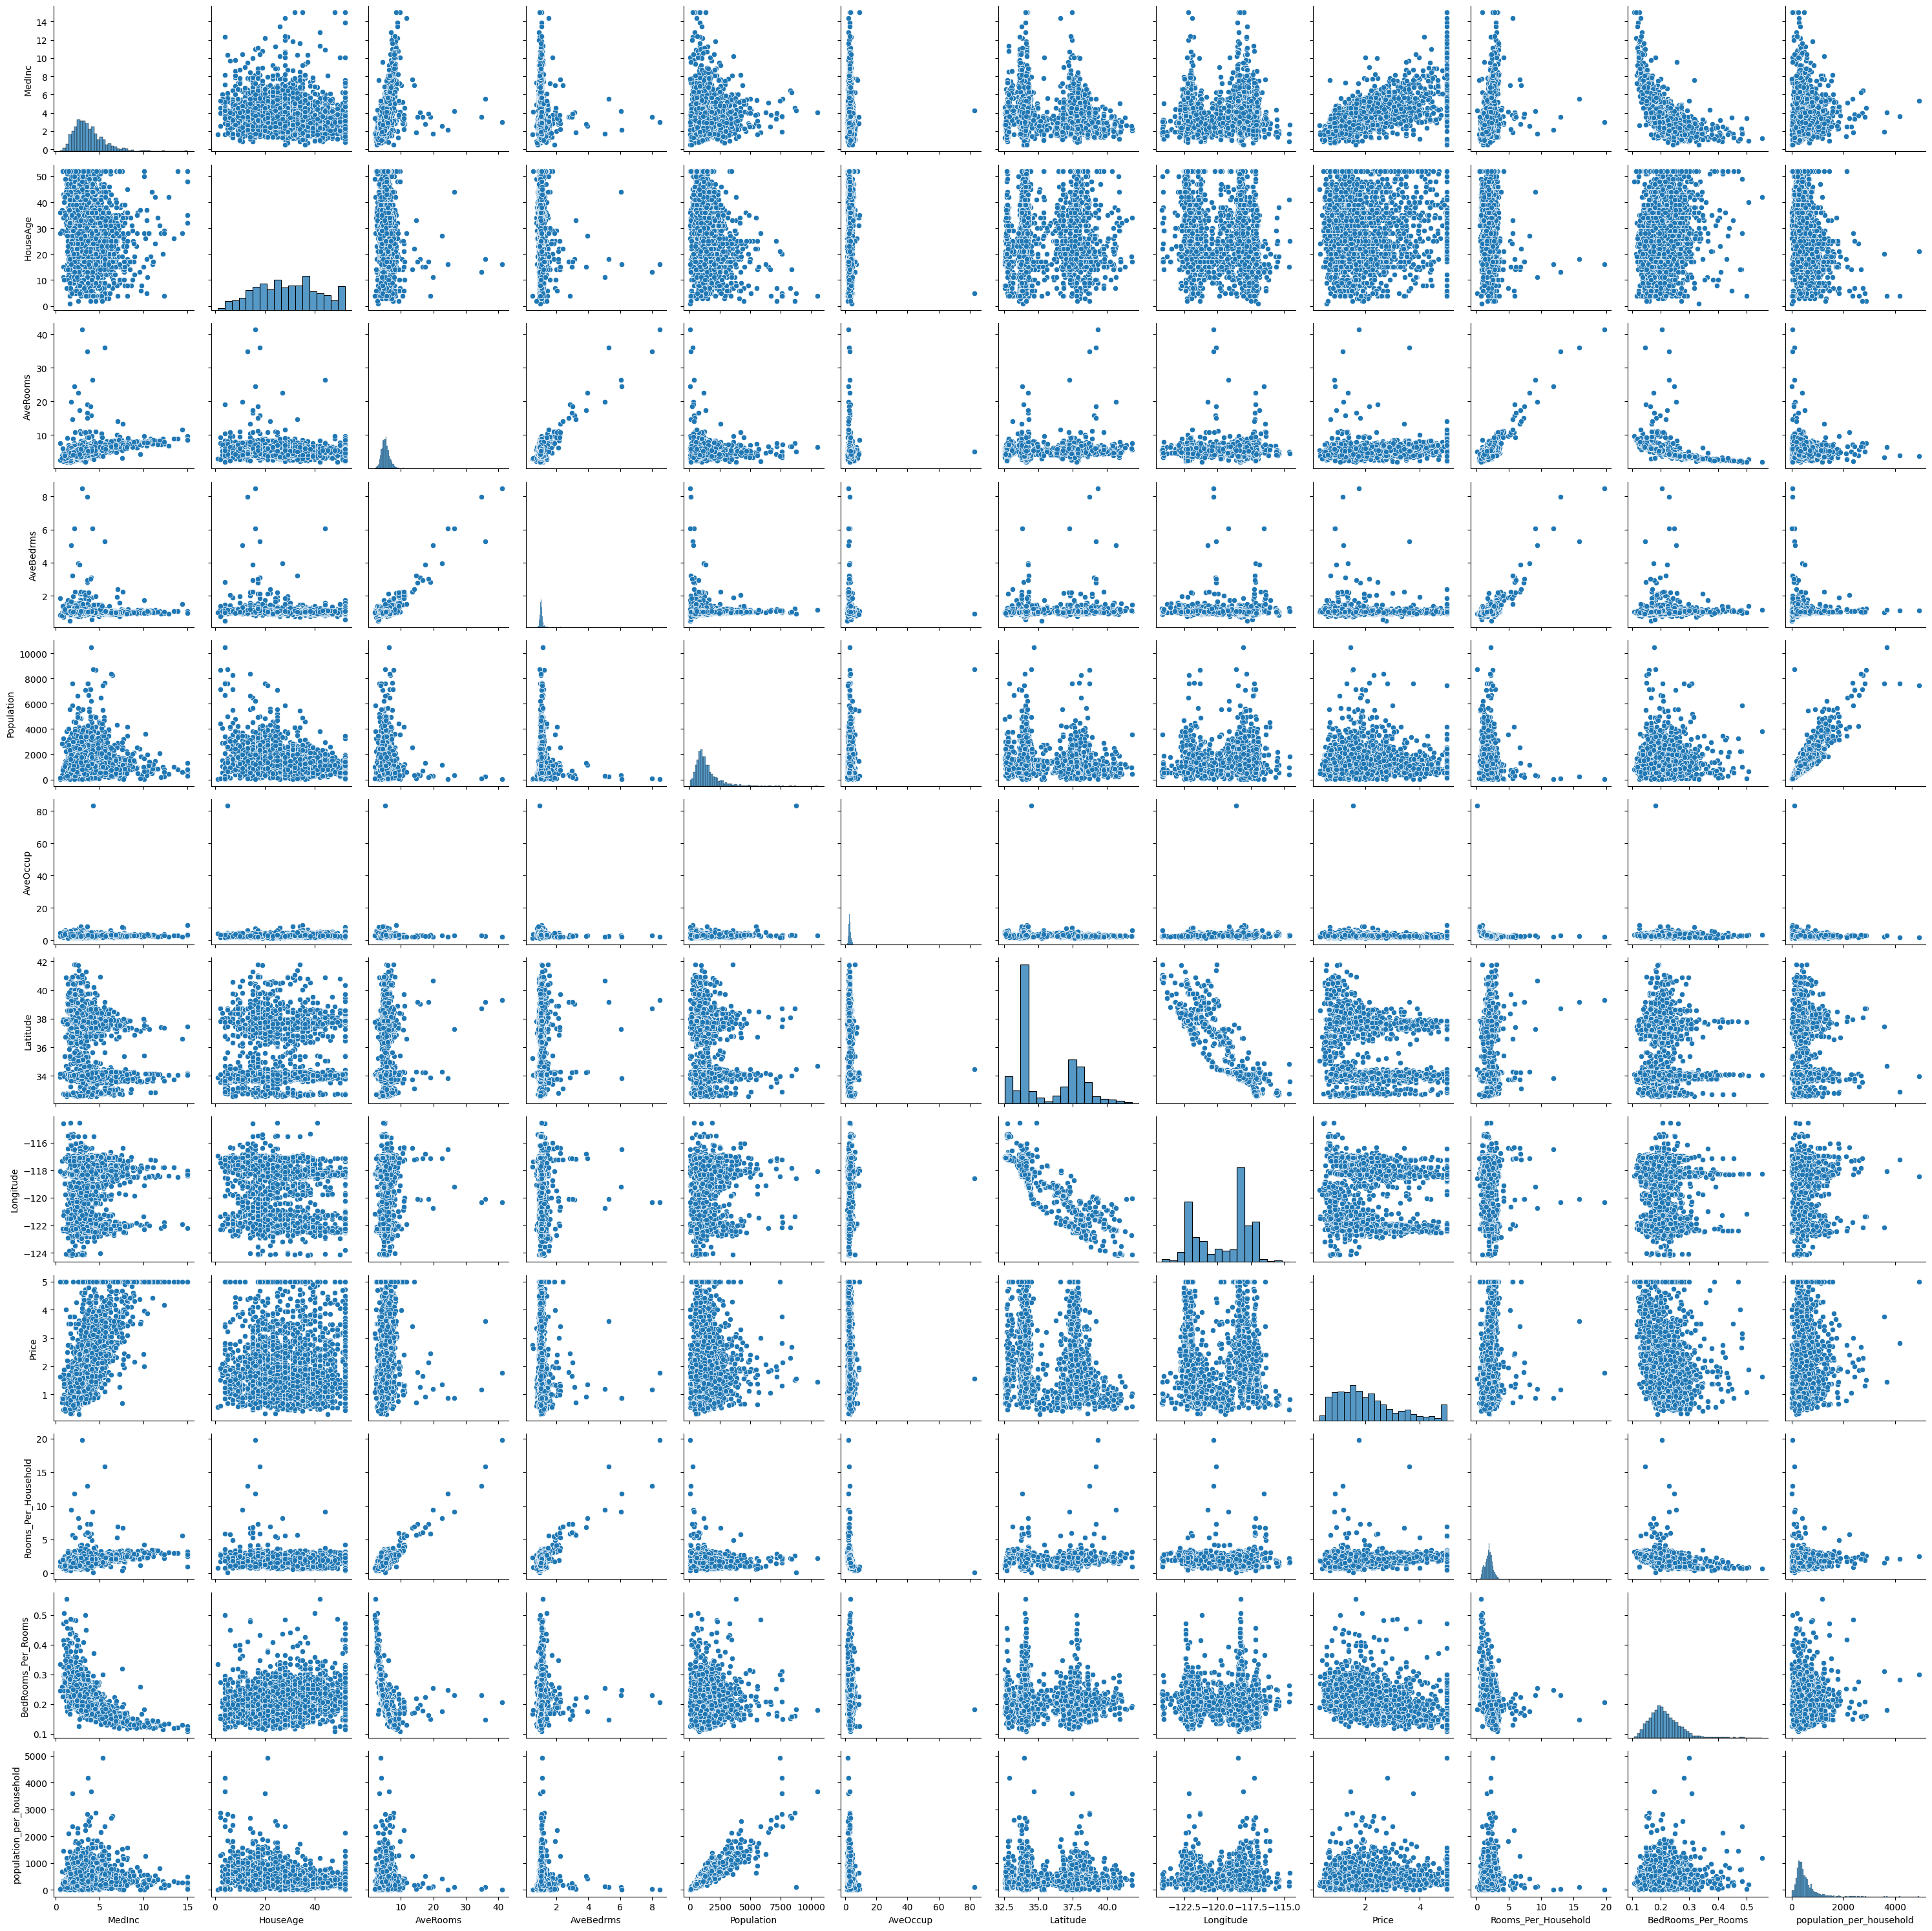

In [14]:
# Pair plot
sns.pairplot(df.sample(2000 , random_state=42))
plt.tight_layout()
plt.show()

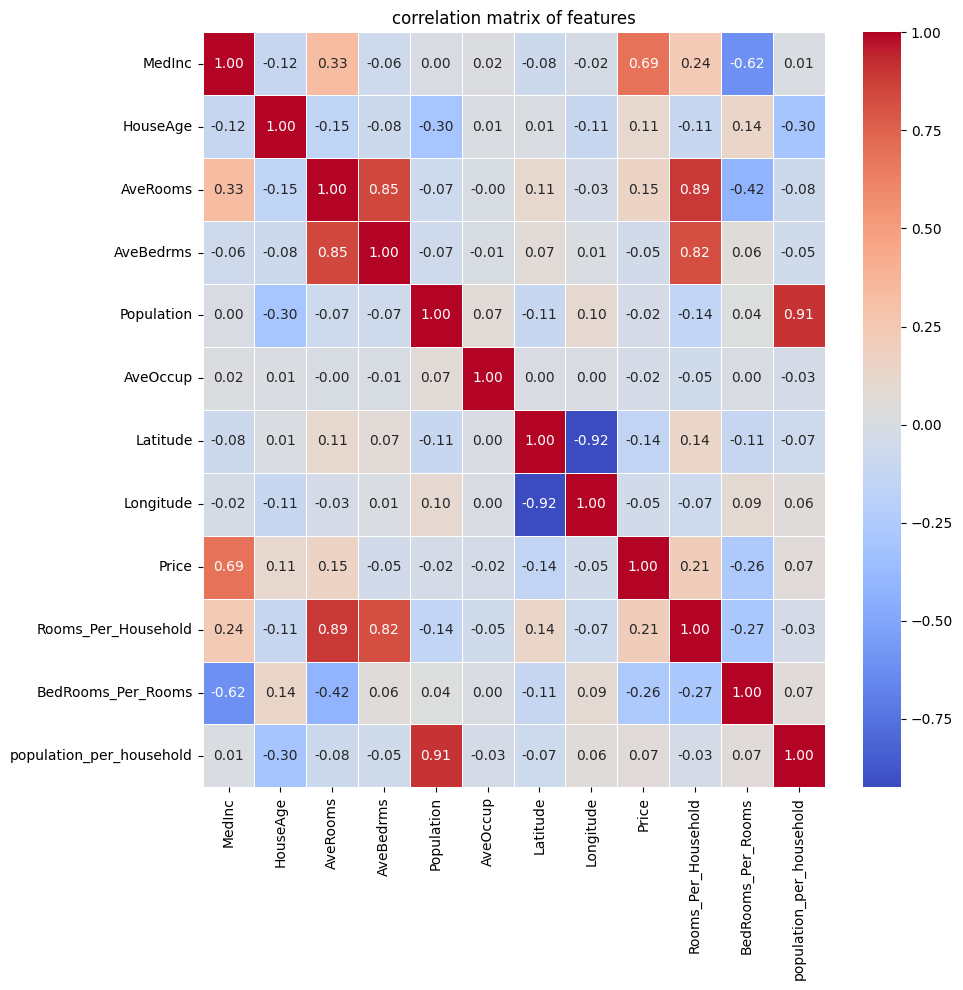

In [15]:
# ploting heatmap to see correlations 
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('correlation matrix of features')
plt.tight_layout()
plt.show()

## **step 5. Build & train ML models**

In [16]:
#independent features and dependent features 
x=df.drop(columns=['Price']) ## all features 
y=df['Price']# all targets(outputs)

print(f'features (x): {x.shape[1]} columns')
print(f'target (y):{y.shape}')

features (x): 11 columns
target (y):(20640,)


In [17]:
# train test my data 
# we will use 70% of data to train and 30% to test.

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [18]:
# standerdizing the dataset
# bring all the features to same scale 
scaler=StandardScaler()# initialisiation
x_train_sc=scaler.fit_transform(x_train)
x_test_sc=scaler.transform(x_test)

print(f'Training set size : {x_train.shape[0]:,} samples')
print(f' Test    set size : {x_test.shape[0]:,} sample')


Training set size : 16,512 samples
 Test    set size : 4,128 sample


In [19]:
#---------model 1 . Linear Regression--------------
# Think of it as drawing a straight line that fits all the data points per
lr=LinearRegression()
lr.fit(x_train_sc,y_train)
print('👍Linear Regression trained!')

#model 2: ridge Regression
rid=Ridge()
rid.fit(x_train_sc,y_train)
print('👍ridge regression trained!')

rf_model=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(x_train, y_train) #tree based model don't require scaled inputs 
print('👍RandomForest Regression trained!')



👍Linear Regression trained!
👍ridge regression trained!
👍RandomForest Regression trained!


## **step 6.Evaluate the models**

In [20]:
def evaluate_model(name , model, x_test_data,y_test_data):
    y_pred = model.predict(x_test_data)
    
    mae=mean_absolute_error(y_test_data,y_pred)
    mse=np.sqrt(mean_squared_error(y_test_data,y_pred))
  
    r2=r2_score(y_test_data,y_pred)
    print(f'\n{'='*50}')
    print(f'📌 {name}')
    print(f'{'='*50}')
    print(f'mean absolute error: {mae:.4f}')
    print(f'{'--'*30}')
    print(f'mean squared error: {mse:.4f}')
    print(f'{'--'*30}')
    print(f'R2 score: {r2:.4f}')
    print()
    print(f'{'**'*30}')

lr_report=evaluate_model('linear regression',lr,x_test_sc,y_test)
rid_report=evaluate_model('ridge regression',rid,x_test_sc,y_test)
rf_model_report=evaluate_model('randomforest regression',rf_model,x_test,y_test)



📌 linear regression
mean absolute error: 0.4874
------------------------------------------------------------
mean squared error: 0.6738
------------------------------------------------------------
R2 score: 0.6535

************************************************************

📌 ridge regression
mean absolute error: 0.4874
------------------------------------------------------------
mean squared error: 0.6738
------------------------------------------------------------
R2 score: 0.6535

************************************************************

📌 randomforest regression
mean absolute error: 0.3298
------------------------------------------------------------
mean squared error: 0.5061
------------------------------------------------------------
R2 score: 0.8045

************************************************************


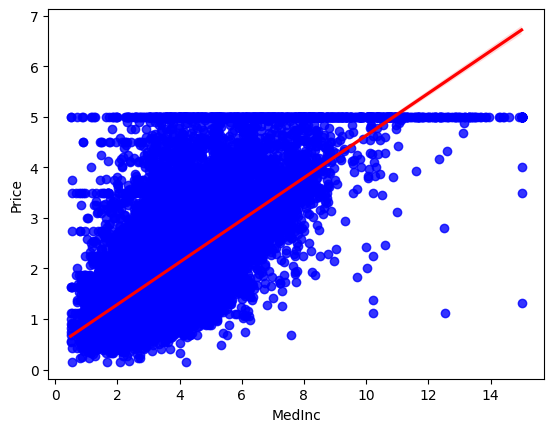

In [21]:
# regression plt : it draws the best fit line especially use for linear regression
sns.regplot(x="MedInc",y=y,data=df,scatter_kws={"color":"blue"},line_kws={"color":"red"})
plt.show()

## **hyperparameter tuning **

In [22]:

#1 Define parameter grid
parameter={
    'n_estimators': [50, 100, 200],      
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
}
    

#2. set up RandomizedSearchCV
rf_random=RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=parameter,
    n_iter=10,   # tries 10 random combinations
    cv=3,        # 3-fold cross validation
    verbose=2,
    random_state=42,
    n_jobs=-1    # use all available CPU cores
    )

In [23]:
print("Tuning hyperparameter......")
rf_random.fit(x_train,y_train)
best_rf_model=rf_random.best_estimator_  #cann't use _best_param_ because it is dictionary of hyperparameters not a fitted model   
                                          # best_estimators_ : already refit on full train data by default   
print("Best parameters found: ",best_rf_model)

Tuning hyperparameter......
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found:  RandomForestRegressor(min_samples_split=5, n_jobs=-1, random_state=42)


In [24]:
# y_pred_tuned = best_rf.predict(x_test)
evaluate_model("Tunned random forest:",best_rf_model,x_test,y_test)


📌 Tunned random forest:
mean absolute error: 0.3295
------------------------------------------------------------
mean squared error: 0.5054
------------------------------------------------------------
R2 score: 0.8051

************************************************************


In [25]:
ridge_pipe=Pipeline([('scaler',StandardScaler()),("ridge",Ridge())])
parameters={'ridge_alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgecv=GridSearchCV(rid,parameters,scoring='neg_mean_squared_error',cv=5)
ridgecv.fit(x_train,y_train)
ridge_pred=ridgecv.predict(x_test)

ValueError: Invalid parameter 'ridge_alpha' for estimator Ridge(). Valid parameters are: ['alpha', 'copy_X', 'fit_intercept', 'max_iter', 'positive', 'random_state', 'solver', 'tol'].

In [ ]:
ridgecv.best_params_

In [ ]:
ridgecv.best_score_

In [ ]:
score=r2_score(y_test,ridge_pred)
score